## Problem

Evaluate

$$I \;=\; \int_{-1}^{+1} \frac{1}{x}\,\sqrt{\frac{1+x}{1-x}}\,\ln\!\left(\frac{1+2x+2x^{2}}{1-2x+2x^{2}}\right)\,dx.$$

### Strategy — complex factoring of the logarithm

The numerator and denominator factor over $\mathbb{C}$:

$$1+2x+2x^{2} = \bigl(1+(1+i)x\bigr)\bigl(1+(1-i)x\bigr), \qquad 1-2x+2x^{2} = \bigl(1-(1+i)x\bigr)\bigl(1-(1-i)x\bigr).$$

Therefore

$$\ln\!\left(\frac{1+2x+2x^{2}}{1-2x+2x^{2}}\right) \;=\; \ln\frac{1+(1+i)x}{1-(1+i)x} + \ln\frac{1+(1-i)x}{1-(1-i)x}.$$

Using $\ln\dfrac{1+y}{1-y} = 2\displaystyle\sum_{k\ge 0}\dfrac{y^{2k+1}}{2k+1}$ and $(1\pm i)=\sqrt{2}\,e^{\pm i\pi/4}$:

$$\ln\!\left(\frac{1+2x+2x^{2}}{1-2x+2x^{2}}\right) \;=\; 4\sum_{k=0}^{\infty}\frac{2^{(2k+1)/2}\cos\!\bigl((2k+1)\tfrac{\pi}{4}\bigr)}{2k+1}\,x^{2k+1}.$$

### Weight integral

With $x=\cos\theta$, $\sqrt{(1+x)/(1-x)}=\cot(\theta/2)$, $dx=-\sin\theta\,d\theta$, and $\sin\theta\,\cot(\theta/2)=1+\cos\theta$:

$$\int_{-1}^{1}\sqrt{\frac{1+x}{1-x}}\,x^{2k}\,dx \;=\; \int_{0}^{\pi}(1+\cos\theta)\cos^{2k}\theta\,d\theta \;=\; \pi\,\frac{\binom{2k}{k}}{4^{k}}.$$

(The $\cos^{2k+1}\theta$ piece vanishes by symmetry.) The factor $1/x$ in the original integrand shifts the series index by one, so

$$I \;=\; 4\pi\sqrt{2}\sum_{k=0}^{\infty}\frac{\binom{2k}{k}}{(2k+1)\,4^{k}}\,\bigl(\sqrt{2}\bigr)^{2k}\cos\!\bigl((2k+1)\tfrac{\pi}{4}\bigr).$$

### Closing the series with $\arcsin$

Recall $\arcsin(z)=\displaystyle\sum_{k\ge 0}\dfrac{\binom{2k}{k}}{4^{k}(2k+1)}\,z^{2k+1}$. Taking $z=1+i=\sqrt{2}\,e^{i\pi/4}$ and extracting the real part collapses the series:

$$I \;=\; 4\pi\,\operatorname{Re}\bigl(\arcsin(1+i)\bigr).$$

Writing $\arcsin(1+i)=u+iv$ gives $\sin u\cosh v=1$ and $\cos u\sinh v=1$, which yields the quadratic $p^{2}-3p+1=0$ for $p=\sin^{2}u$. The admissible root is $p=\tfrac{3-\sqrt{5}}{2}=1/\varphi^{2}$, where $\varphi=\tfrac{1+\sqrt{5}}{2}$ is the golden ratio. Hence $\sin u = 1/\varphi$ and

$$\boxed{\;I \;=\; 4\pi\,\arcsin\!\left(\frac{1}{\varphi}\right) \;=\; 4\pi\,\arcsin\!\left(\frac{\sqrt{5}-1}{2}\right) \;\approx\; 8.37221162660\ldots\;}$$


In [1]:
import numpy as np
from scipy.integrate import quad


def integrand(x):
    if abs(x) < 1e-12:
        return 4.0  # removable singularity: lim_{x->0} = 4
    return (
        (1.0 / x)
        * np.sqrt((1 + x) / (1 - x))
        * np.log((1 + 2 * x + 2 * x * x) / (1 - 2 * x + 2 * x * x))
    )


I_numeric, abs_err = quad(integrand, -1, 1, limit=400)

phi = (1 + np.sqrt(5)) / 2
I_closed = 4 * np.pi * np.arcsin(1 / phi)
I_via_arcsin = 4 * np.pi * np.arcsin(1 + 1j).real

print(f"Numerical (scipy.quad):  {I_numeric:.14f}   (est. error {abs_err:.2e})")
print(f"4*pi*Re(arcsin(1+i)):    {I_via_arcsin:.14f}")
print(f"4*pi*arcsin(1/phi):      {I_closed:.14f}")
print(f"|numeric - closed|:      {abs(I_numeric - I_closed):.2e}")

Numerical (scipy.quad):  8.37221162660023   (est. error 1.86e-08)
4*pi*Re(arcsin(1+i)):    8.37221162660128
4*pi*arcsin(1/phi):      8.37221162660127
|numeric - closed|:      1.04e-12


In [2]:
# Cross-check the two key algebraic claims used in the derivation:
#   (1) sqrt((3 - sqrt 5)/2) == 1/phi      (i.e. sin u = 1/phi)
#   (2) Re(arcsin(1+i)) == arcsin(1/phi)
import numpy as np

phi = (1 + np.sqrt(5)) / 2
p = (3 - np.sqrt(5)) / 2

print(f"sqrt((3-sqrt5)/2):  {np.sqrt(p):.15f}")
print(f"1/phi:              {1 / phi:.15f}")
print(f"p^2 - 3p + 1:       {p * p - 3 * p + 1:.2e}   (should be 0)")
print()
print(f"Re(arcsin(1+i)):    {np.arcsin(1 + 1j).real:.15f}")
print(f"arcsin(1/phi):      {np.arcsin(1 / phi):.15f}")
print()
print(f"I = 4*pi*arcsin(1/phi) = {4 * np.pi * np.arcsin(1 / phi):.15f}")

sqrt((3-sqrt5)/2):  0.618033988749895
1/phi:              0.618033988749895
p^2 - 3p + 1:       1.11e-16   (should be 0)

Re(arcsin(1+i)):    0.666239432492515
arcsin(1/phi):      0.666239432492515

I = 4*pi*arcsin(1/phi) = 8.372211626601274


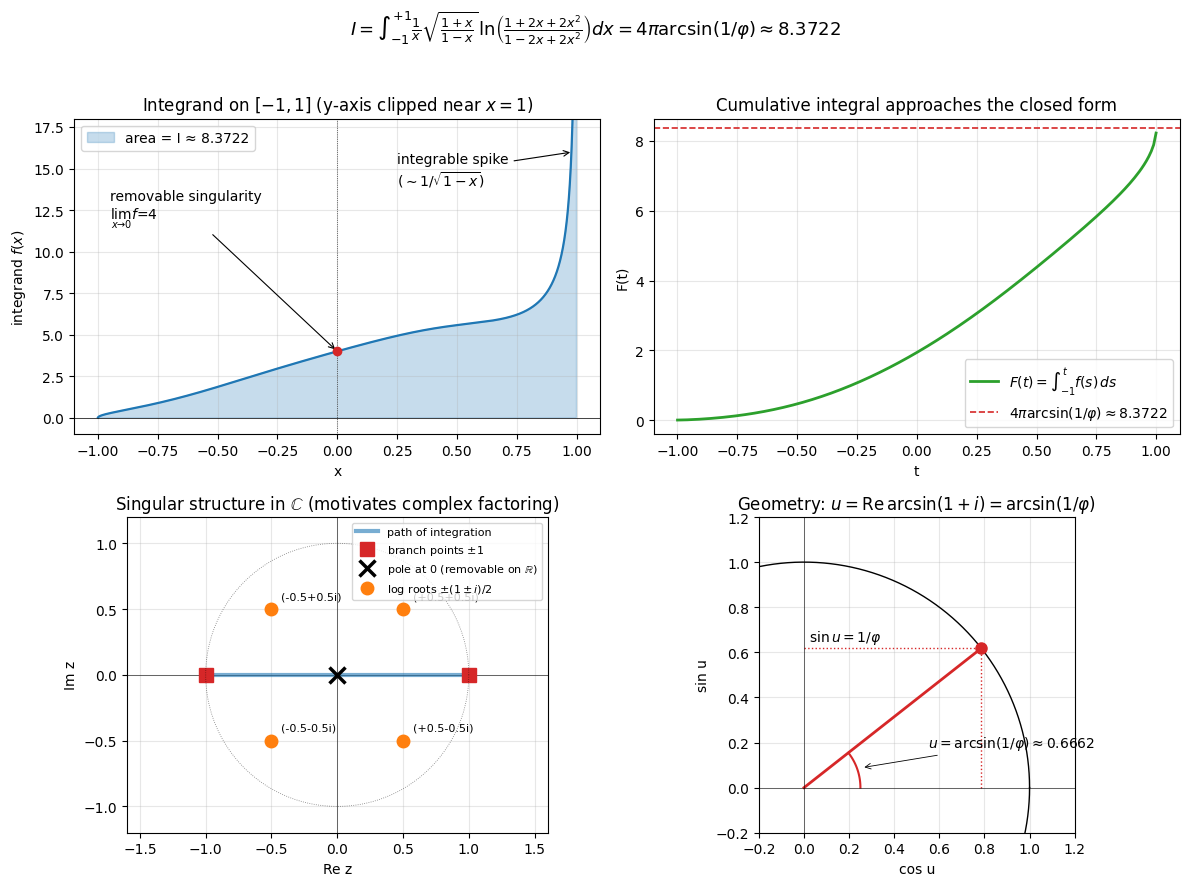

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

phi = (1 + np.sqrt(5)) / 2
I_exact = 4 * np.pi * np.arcsin(1 / phi)


def f(x):
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    mask = np.abs(x) < 1e-12
    out[mask] = 4.0  # removable limit at x=0
    xs = x[~mask]
    out[~mask] = (
        (1 / xs)
        * np.sqrt((1 + xs) / (1 - xs))
        * np.log((1 + 2 * xs + 2 * xs**2) / (1 - 2 * xs + 2 * xs**2))
    )
    return out


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    r"$I=\int_{-1}^{+1}\frac{1}{x}\sqrt{\frac{1+x}{1-x}}\,"
    r"\ln\!\left(\frac{1+2x+2x^{2}}{1-2x+2x^{2}}\right)dx"
    r"=4\pi\arcsin(1/\varphi)\approx 8.3722$",
    fontsize=13,
)

# -- (1) The integrand on (-1, 1) with the area shaded (y-axis clipped) --
ax = axes[0, 0]
xs = np.linspace(-0.9999, 0.9999, 4001)
ys = f(xs)
ax.fill_between(xs, ys, alpha=0.25, color="C0", label=f"area = I ≈ {I_exact:.4f}")
ax.plot(xs, ys, color="C0", lw=1.6)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.plot(0, 4.0, "o", color="C3", ms=6, zorder=5)
ax.annotate(
    "removable singularity\n$\\lim_{x\\to 0}f = 4$",
    xy=(0, 4),
    xytext=(-0.95, 12),
    arrowprops=dict(arrowstyle="->", lw=0.8),
)
ax.annotate(
    "integrable spike\n($\\sim 1/\\sqrt{1-x}$)",
    xy=(0.985, 16),
    xytext=(0.25, 14),
    arrowprops=dict(arrowstyle="->", lw=0.8),
)
ax.set_xlabel("x")
ax.set_ylabel("integrand $f(x)$")
ax.set_ylim(-1, 18)  # clip the spike for readability
ax.set_title("Integrand on $[-1,1]$ (y-axis clipped near $x=1$)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

# -- (2) Cumulative integral F(t) = \int_{-1}^t f(s) ds --
ax = axes[0, 1]
ts = np.linspace(-0.999, 0.999, 200)
Fs = np.array([quad(f, -1, t, limit=200)[0] for t in ts])
ax.plot(ts, Fs, color="C2", lw=2, label=r"$F(t)=\int_{-1}^{t} f(s)\,ds$")
ax.axhline(
    I_exact,
    color="C3",
    ls="--",
    lw=1.2,
    label=rf"$4\pi\arcsin(1/\varphi)\approx{I_exact:.4f}$",
)
ax.set_xlabel("t")
ax.set_ylabel("F(t)")
ax.set_title("Cumulative integral approaches the closed form")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# -- (3) Complex-plane fingerprint of the integrand --
ax = axes[1, 0]
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)
ax.plot([-1, 1], [0, 0], color="C0", lw=3, alpha=0.6, label="path of integration")
ax.plot([-1, 1], [0, 0], "s", color="C3", ms=10, label=r"branch points $\pm 1$")
ax.plot(
    0,
    0,
    "x",
    color="k",
    ms=12,
    mew=2.5,
    label="pole at $0$ (removable on $\\mathbb{R}$)",
)
roots = np.array([(1 + 1j) / 2, (1 - 1j) / 2, (-1 + 1j) / 2, (-1 - 1j) / 2])
ax.plot(
    roots.real, roots.imag, "o", color="C1", ms=9, label=r"log roots $\pm(1\pm i)/2$"
)
for r in roots:
    ax.annotate(
        f"({r.real:+.1f}{r.imag:+.1f}i)",
        (r.real, r.imag),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=8,
    )
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k:", lw=0.6, alpha=0.5)
ax.set_xlim(-1.6, 1.6)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xlabel("Re z")
ax.set_ylabel("Im z")
ax.set_title("Singular structure in $\\mathbb{C}$ (motivates complex factoring)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# -- (4) Why 1/phi: arcsin(1+i) and the golden-ratio angle --
ax = axes[1, 1]
u = np.arcsin(1 / phi)  # = Re(arcsin(1+i))
sin_u, cos_u = 1 / phi, np.sqrt(1 - 1 / phi**2)
ax.plot(np.cos(theta), np.sin(theta), "k-", lw=1)  # unit circle
ax.plot([0, cos_u], [0, sin_u], "C3-", lw=2)  # radius
ax.plot(cos_u, sin_u, "o", color="C3", ms=8)
ax.plot([0, cos_u], [sin_u, sin_u], "C3:", lw=1)
ax.plot([cos_u, cos_u], [0, sin_u], "C3:", lw=1)
arc = np.linspace(0, u, 60)
ax.plot(0.25 * np.cos(arc), 0.25 * np.sin(arc), "C3-", lw=1.5)
ax.annotate(
    rf"$u=\arcsin(1/\varphi)\approx{u:.4f}$",
    xy=(0.27 * np.cos(u / 2), 0.27 * np.sin(u / 2)),
    xytext=(0.55, 0.18),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", lw=0.6),
)
ax.annotate(r"$\sin u = 1/\varphi$", xy=(0.02, sin_u + 0.03), fontsize=10)
ax.axhline(0, color="k", lw=0.4)
ax.axvline(0, color="k", lw=0.4)
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_aspect("equal")
ax.set_xlabel("cos u")
ax.set_ylabel("sin u")
ax.set_title(r"Geometry: $u=\mathrm{Re}\,\arcsin(1+i)=\arcsin(1/\varphi)$")
ax.grid(alpha=0.3)

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()